In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
import scipy as sp
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq, rfft, rfftfreq
from scipy.signal import find_peaks
from matplotlib import gridspec


# Data loading

We will catagorize audio samples to determine whether there are drones present. 

The data is sourced from Kaggle at https://www.kaggle.com/datasets/amineipad/drone-sound-audio-detection

The data is split into unknown files and yes_drone files. Lets load one of the yes_drone files. 

In [2]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
samplerate, data = wavfile.read(base + filename)
#samplerate, data = wavfile.read()

print(f"Sample Rate: {samplerate} Hz")
print(f"Data Shape: {data.shape}")
print(f'length of clip: {data.shape[0] / samplerate} seconds')

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


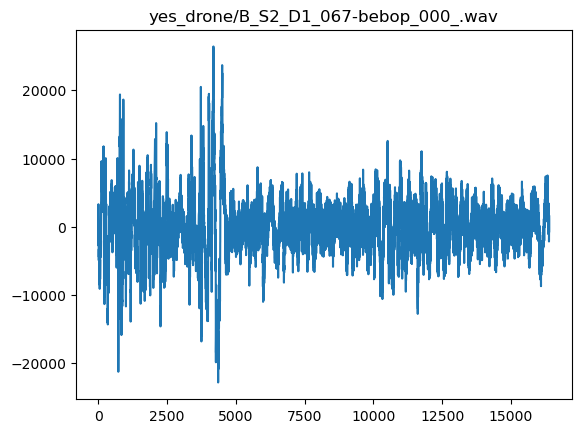

In [3]:
plt.plot(data)
plt.title(filename)
plt.show()
plt.close()

That looks like an audio file, good!

## Types of files

Lets look at the types of files we have in our data set

The data is located in `\Binary_Drone_Audio` with two folders: `unknown` and `yes_drone`.

In [4]:
import glob
glob.glob('Binary_Drone_Audio/*')

['Binary_Drone_Audio/yes_drone', 'Binary_Drone_Audio/unknown']

The `yes_drone` folder has `.wav` files tagged as drone noises. There are 1332 `yes_drone` files.

The `unknown` folder has `.wav` files tagged as drone noises. There are 10372 `unknown` files.

Each file is around 30 kb, with 67 `unknown` files ~160 kb

In [5]:
yes_drone_files = glob.glob('Binary_Drone_Audio/yes_drone/*')
unknown_files = glob.glob('Binary_Drone_Audio/unknown/*')
len(yes_drone_files), len(unknown_files)

(1332, 10372)

In [6]:
1 - (len(yes_drone_files) / len(unknown_files))

0.8715773235634401

There are the following types of files in `yes_drone`:

* B_S2_D1_*_bebop_000 - 004
* extra_membo_D2_2000 - 2025
* Membo_0_***_membo_000 - 004
* Membo_1_***_membo_000 - 004
* Membo_2_***_membo_000 - 004
* mixed_..._bebop_000 - 004
* mixed_membo..._000 - 004

bebop --> Parrot Bebop, membo --> mambo drone? 

There are the following types of files in `unknown`:

* 1_... - 5_...
* doing_the_dishes
* exercise_bike
* pink_noise
* running_tap
* silence
* white_noise

## Waveforms

Lets look at a waveform from each yes type:

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


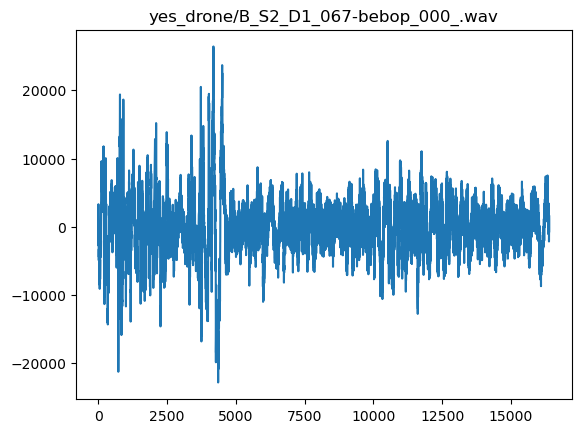

40.0 Hz, amplitude 1358.691
92.8 Hz, amplitude 708.183
160.2 Hz, amplitude 521.262
67.4 Hz, amplitude 496.898
124.0 Hz, amplitude 453.911
216.8 Hz, amplitude 422.604
390.6 Hz, amplitude 367.863
184.6 Hz, amplitude 330.039
266.6 Hz, amplitude 305.127
307.6 Hz, amplitude 244.895


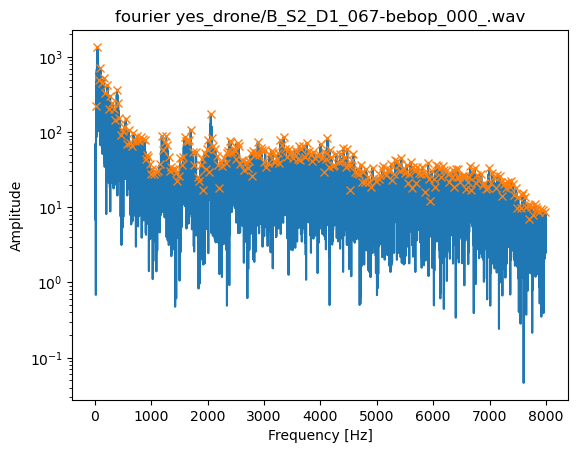

Sample Rate: 16000 Hz
Data Shape: (16027,)
length of clip: 1.0016875 seconds


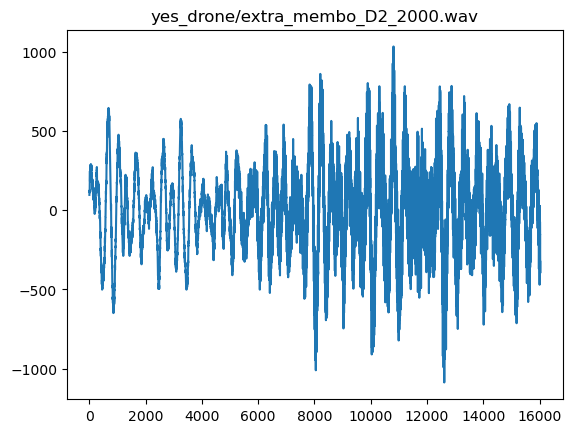

37.9 Hz, amplitude 157.917
17.0 Hz, amplitude 22.253
98.8 Hz, amplitude 20.787
75.9 Hz, amplitude 19.493
1254.9 Hz, amplitude 9.860
1791.0 Hz, amplitude 8.899
1834.9 Hz, amplitude 8.856
2526.7 Hz, amplitude 8.585
580.0 Hz, amplitude 8.212
1714.1 Hz, amplitude 7.886


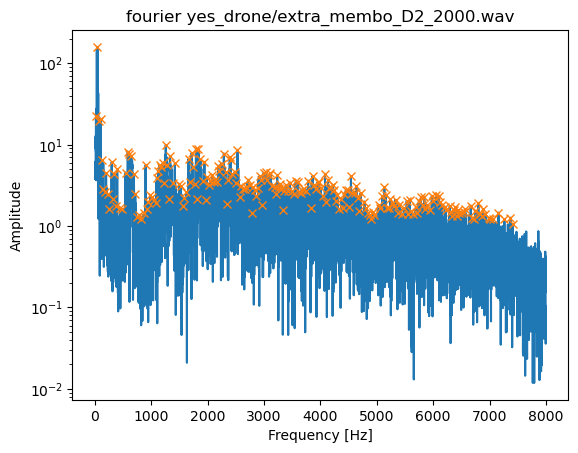

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


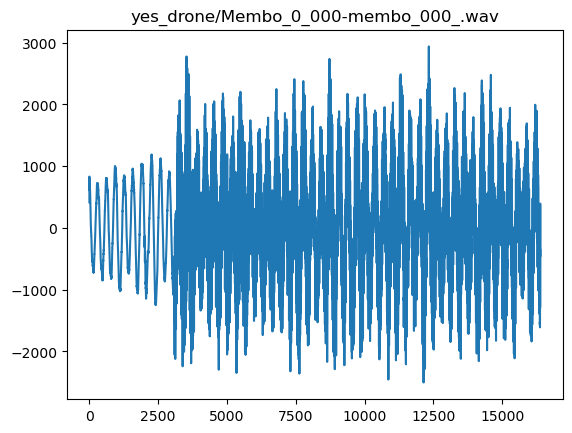

48.8 Hz, amplitude 597.153
637.7 Hz, amplitude 260.066
612.3 Hz, amplitude 97.328
1862.3 Hz, amplitude 78.246
1275.4 Hz, amplitude 69.645
24.4 Hz, amplitude 59.035
1249.0 Hz, amplitude 51.615
2499.0 Hz, amplitude 43.662
918.9 Hz, amplitude 43.657
3192.4 Hz, amplitude 41.652


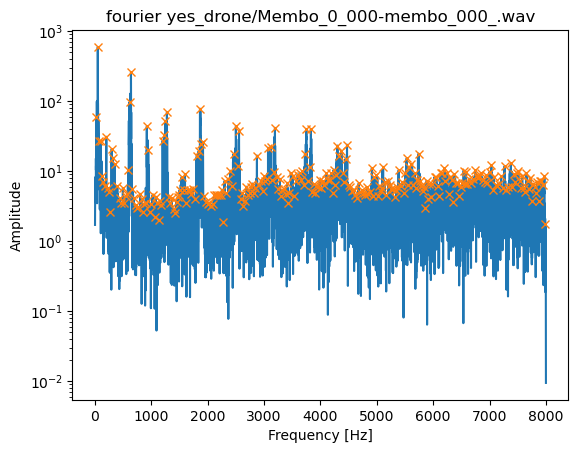

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


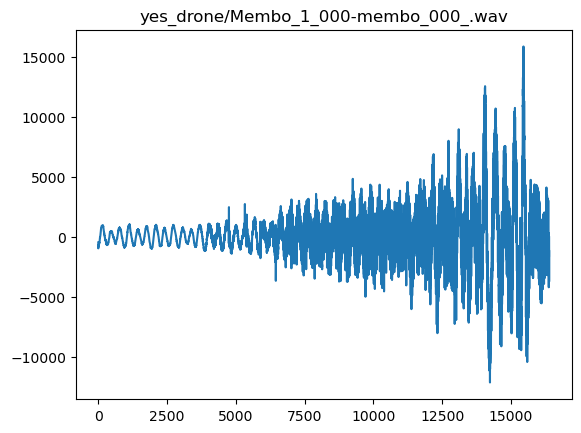

48.8 Hz, amplitude 870.200
69.3 Hz, amplitude 431.460
24.4 Hz, amplitude 223.960
92.8 Hz, amplitude 214.236
673.8 Hz, amplitude 152.943
625.0 Hz, amplitude 137.389
574.2 Hz, amplitude 119.681
651.4 Hz, amplitude 110.356
141.6 Hz, amplitude 87.128
116.2 Hz, amplitude 72.063


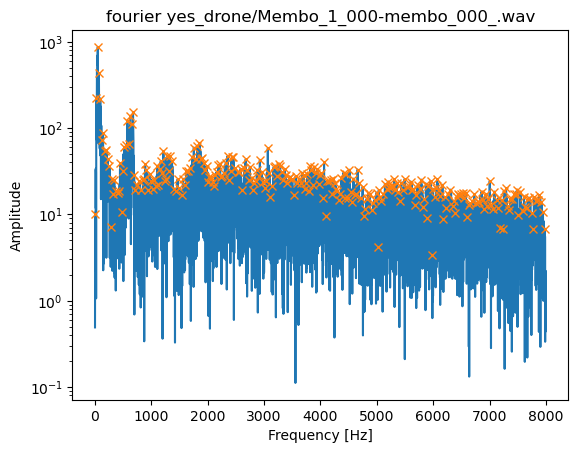

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


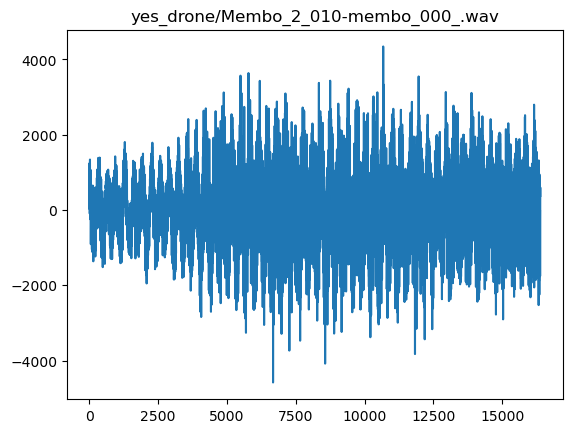

49.8 Hz, amplitude 569.061
1273.4 Hz, amplitude 87.153
1221.7 Hz, amplitude 83.541
641.6 Hz, amplitude 83.206
3202.1 Hz, amplitude 82.539
1182.6 Hz, amplitude 69.802
593.8 Hz, amplitude 68.996
1797.9 Hz, amplitude 63.191
4494.1 Hz, amplitude 57.264
1928.7 Hz, amplitude 56.430


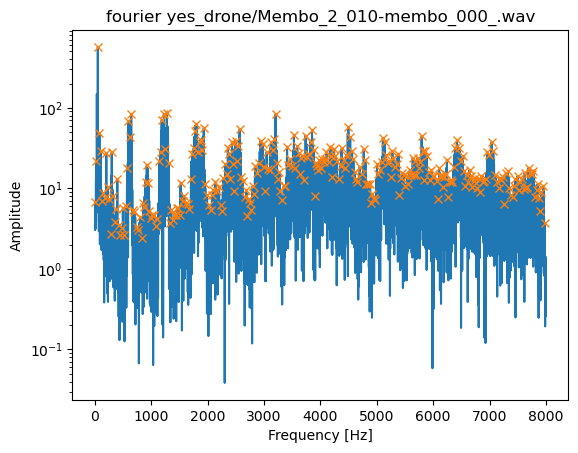

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


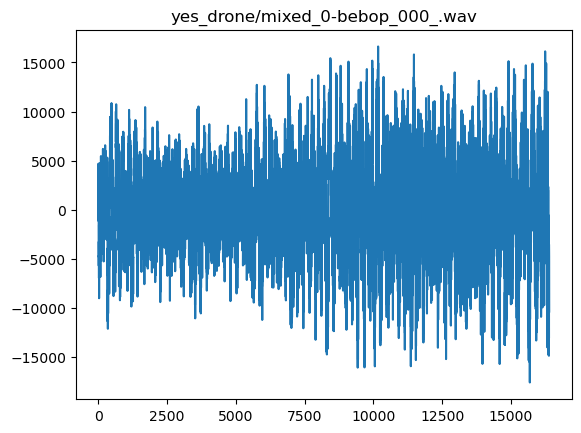

74.2 Hz, amplitude 1987.704
47.9 Hz, amplitude 627.879
120.1 Hz, amplitude 595.106
301.8 Hz, amplitude 486.180
321.3 Hz, amplitude 446.275
243.2 Hz, amplitude 409.309
280.3 Hz, amplitude 377.811
350.6 Hz, amplitude 375.518
98.6 Hz, amplitude 308.357
218.8 Hz, amplitude 296.598


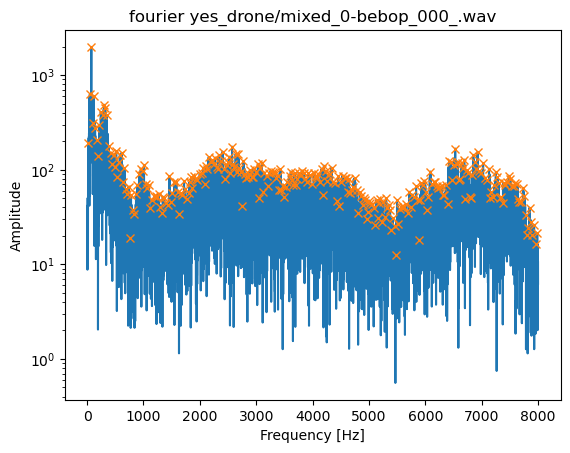

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


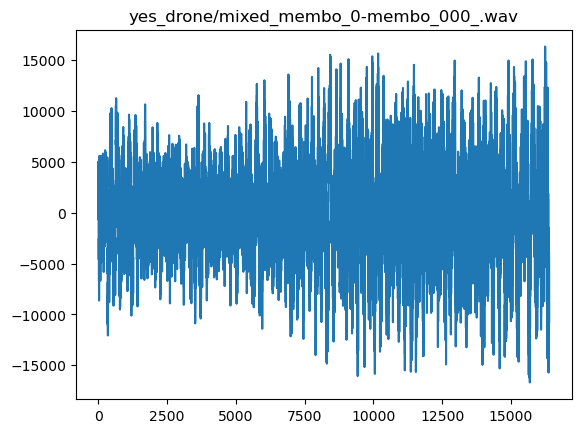

74.2 Hz, amplitude 2006.962
49.8 Hz, amplitude 729.600
120.1 Hz, amplitude 597.541
301.8 Hz, amplitude 484.589
321.3 Hz, amplitude 443.947
243.2 Hz, amplitude 408.301
280.3 Hz, amplitude 379.177
350.6 Hz, amplitude 373.819
97.7 Hz, amplitude 308.121
218.8 Hz, amplitude 298.037


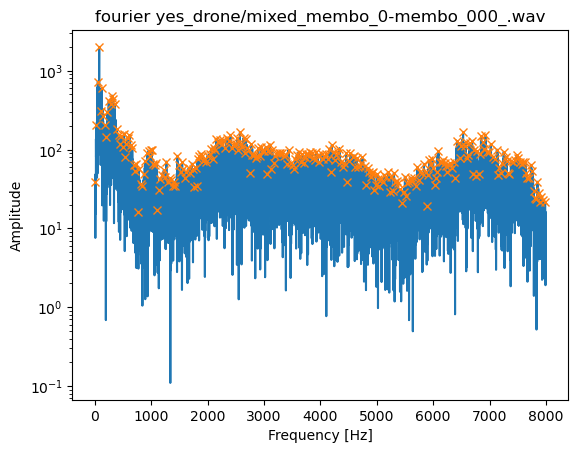

In [7]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'

filenames_yes = ['yes_drone/B_S2_D1_067-bebop_000_.wav', 'yes_drone/extra_membo_D2_2000.wav', 'yes_drone/Membo_0_000-membo_000_.wav', 
                 'yes_drone/Membo_1_000-membo_000_.wav', 'yes_drone/Membo_2_010-membo_000_.wav', 'yes_drone/mixed_0-bebop_000_.wav',
                 'yes_drone/mixed_membo_0-membo_000_.wav']

for filename in filenames_yes:
    samplerate, data = wavfile.read(base + filename)
    #samplerate, data = wavfile.read()
    
    N = data.shape[0]
    T = 1.0 / samplerate

    print(f"Sample Rate: {samplerate} Hz")
    print(f"Data Shape: {data.shape}")
    print(f'length of clip: {data.shape[0] / samplerate} seconds')

    plt.plot(data)
    plt.title(filename)
    plt.show()
    plt.close()

    yf = rfft(data)
    xf = rfftfreq(N, T)

    magnitude = np.abs(yf) * 2.0 / N

    peaks, properties = find_peaks(magnitude, prominence=1, distance=20)

    peak_freqs = xf[peaks]
    peak_amps  = magnitude[peaks]

    idx = np.argsort(peak_amps)[::-1]

    peak_freqs = peak_freqs[idx]
    peak_amps  = peak_amps[idx]

    for f, a in zip(peak_freqs[:10], peak_amps[:10]):
        print(f"{f:.1f} Hz, amplitude {a:.3f}")

    plt.plot(xf, magnitude)
    plt.plot(xf[peaks], magnitude[peaks], 'x')
    plt.semilogy()
    plt.title(f'fourier {filename}')
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude")
    plt.show()

## dB plot

Sample Rate: 16000 Hz
Data Shape: (16384,)
length of clip: 1.024 seconds


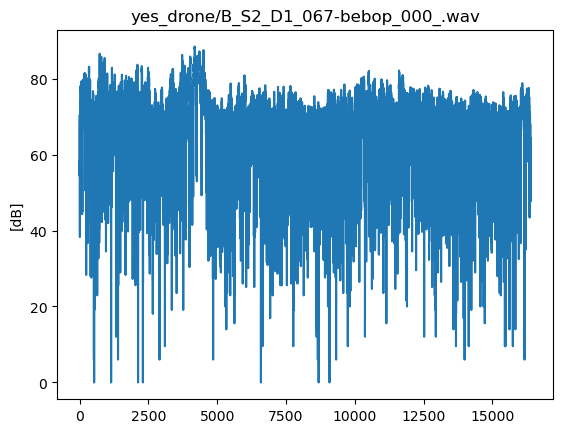

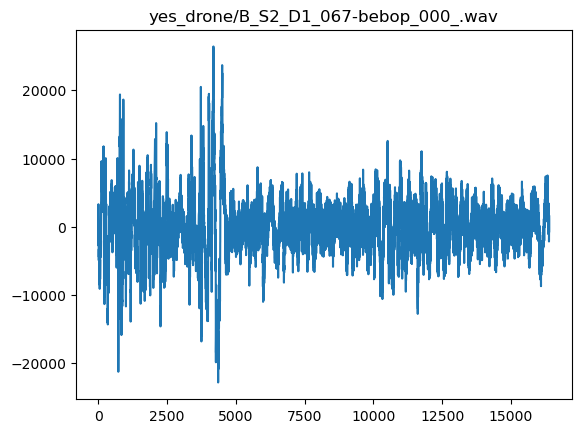

In [8]:
def convert_to_decibel(arr):
    ref = 1
    if arr!=0:
        return 20 * np.log10(abs(arr) / ref)
        
    else:
        return -60
    
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
samplerate, data = wavfile.read(base + filename)

dataDB = [convert_to_decibel(i) for i in data]
print(f"Sample Rate: {samplerate} Hz")
print(f"Data Shape: {data.shape}")
print(f'length of clip: {data.shape[0] / samplerate} seconds')

plt.plot(dataDB)
plt.title(filename)
plt.ylabel('[dB]')
plt.show()
plt.close()

plt.plot(data)
plt.title(filename)
plt.show()
plt.close()

## What to extract

taken form ml finding drones here: 10.1016/j.procs.2022.09.140

* Chromagram: Provides a representation of the chromagram automatically collected from a waveform; Spectral Centroid: indicates where the ’centre of mass’ of an audio sample is located and this characteristic can be obtained as the relative average of the audio frequencies; 
* Spectral Bandwidth: as the name suggests, it relates to the bandwidth of the spectrum; 
* Spectral Rolloff: is represented as the frequency below which a certain percentage of the total spectral energy lies
* Mel-Frequency Cepstral Coefficients: indicated with the acronym Mel-Frequency Cepstral Coefficients: referred to as MFCC, is used to represent the shape of a spectral envelope. The The range of numerical values that this function can assume goes from 1 to 20. 20

### Chromagram 



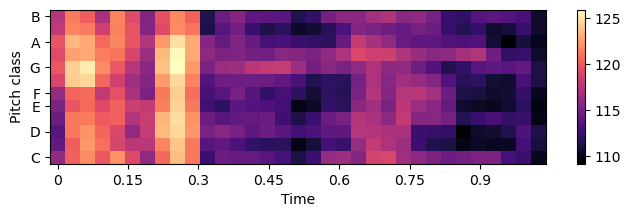

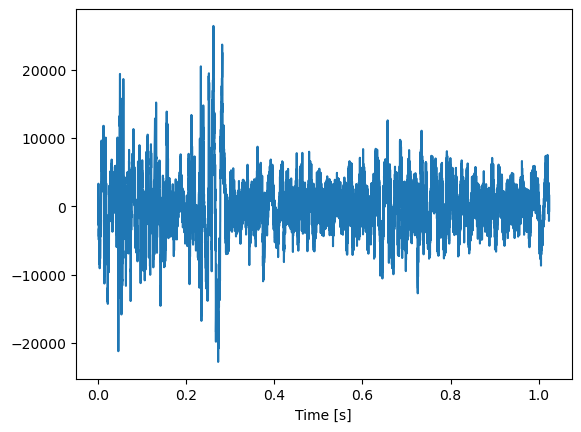

In [9]:
import librosa, librosa.display

base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
samplerate, data = wavfile.read(base + filename)
#samplerate, data = wavfile.read()

C = librosa.feature.chroma_stft(y=data.astype(float), sr=samplerate, tuning=0, norm=None, n_fft=2000)
eps = np.finfo(float).eps
plt.figure(figsize=(8, 2))
librosa.display.specshow(10 * np.log10(eps + C), x_axis='time', 
                         y_axis='chroma', sr=samplerate)
plt.colorbar()
plt.show()
plt.close()

times = [i / samplerate for i in range(data.shape[0])]
plt.plot(times, data)
plt.xlabel('Time [s]')
plt.show()
plt.close()

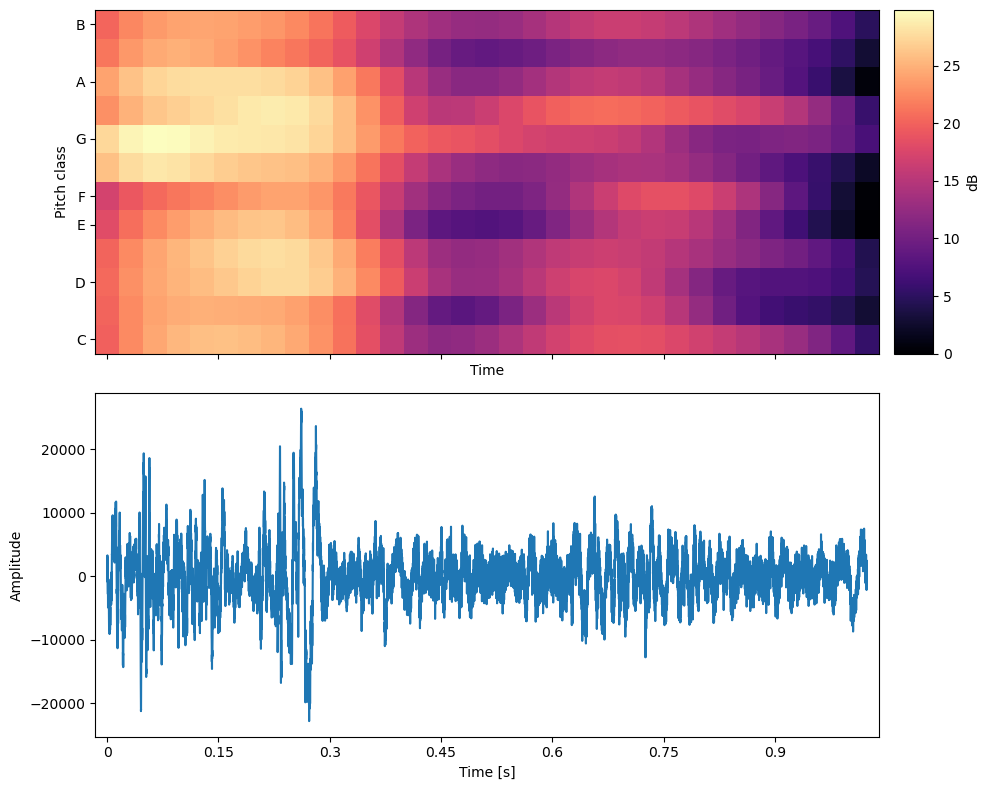

In [10]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
samplerate, data = wavfile.read(base + filename)
#samplerate, data = wavfile.read()

if data.ndim > 1:
    data = data.mean(axis=1)

C = librosa.feature.chroma_stft(
    y=data.astype(float),
    sr=samplerate,
    tuning=0,
    norm=None,
    n_fft=8000
)

eps = np.finfo(float).eps
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[20, 1],  
    height_ratios=[1, 1]
)


avg = 0
totLen = 0
for i in C:
    totLen = totLen + len(i)
    avg = avg + i.sum()
avg = avg / totLen
minC = C.min()

ax_main = fig.add_subplot(gs[0, 0])
img = librosa.display.specshow(
    20 * np.log10((eps + C) / minC),
    x_axis='time',
    y_axis='chroma',
    sr=samplerate,
    ax=ax_main
)

cax = fig.add_subplot(gs[0, 1])
fig.colorbar(img, cax=cax)
cax.set_ylabel('dB')

times = np.arange(len(data)) / samplerate
ax_residuals = fig.add_subplot(gs[1, 0], sharex=ax_main)
ax_residuals.plot(times, data)
ax_residuals.set_xlabel('Time [s]')
ax_residuals.set_ylabel('Amplitude')

plt.setp(ax_main.get_xticklabels(), visible=False)

plt.tight_layout()
plt.show()

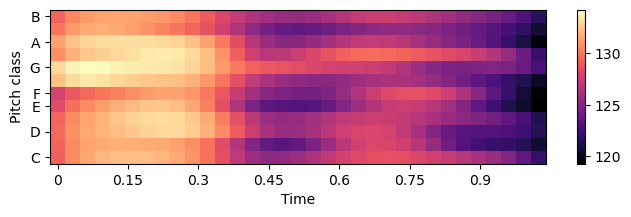

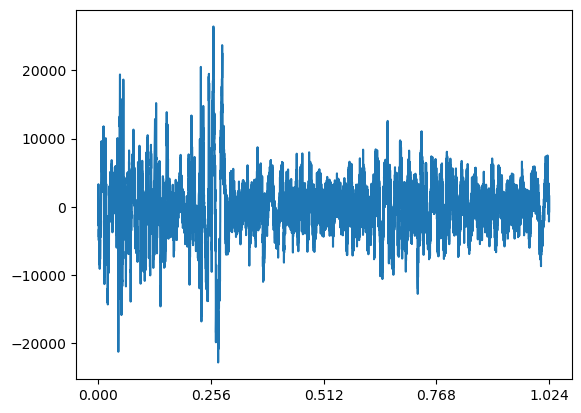

In [11]:
plt.figure(figsize=(8, 2))
librosa.display.specshow(10 * np.log10(eps + C), x_axis='time', 
                         y_axis='chroma', sr=samplerate)

plt.colorbar()
plt.show()
plt.close()

def GetSpacedElements(array, numElems = 4):
    out = array[np.round(np.linspace(0, len(array)-1, numElems)).astype(int)]
    return out

plt.plot(times, data)

plt.xticks(GetSpacedElements(times,5))
plt.show()
plt.close()


### Spectral Centroid



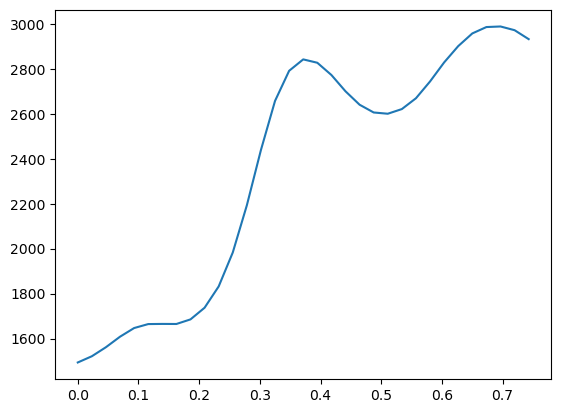

[0.         0.02321995 0.04643991 0.06965986 0.09287982 0.11609977
 0.13931973 0.16253968 0.18575964 0.20897959 0.23219955 0.2554195
 0.27863946 0.30185941 0.32507937 0.34829932 0.37151927 0.39473923
 0.41795918 0.44117914 0.46439909 0.48761905 0.510839   0.53405896
 0.55727891 0.58049887 0.60371882 0.62693878 0.65015873 0.67337868
 0.69659864 0.71981859 0.74303855]


In [12]:
spectral_centroid = librosa.feature.spectral_centroid(y=data.astype(float), sr=samplerate, n_fft = 8000)
times = librosa.times_like(spectral_centroid)

plt.plot(times, spectral_centroid.T)
plt.show()
plt.close()

print(times)


[Text(0.5, 1.0, 'log Power spectrogram')]

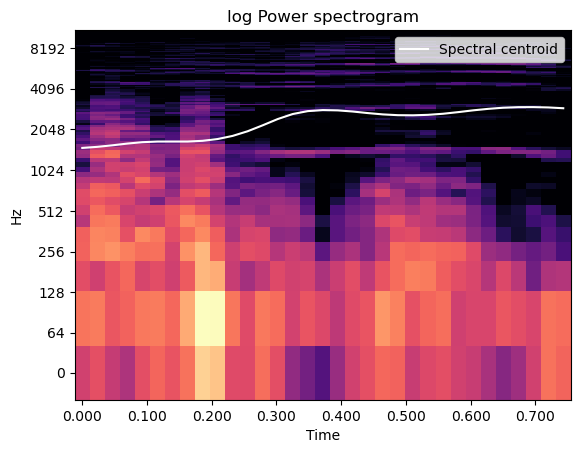

In [13]:
S = librosa.feature.melspectrogram(y=data.astype(float), sr=samplerate, n_mels=128,
                                   fmax=8000)
times = librosa.times_like(spectral_centroid)
fig, ax = plt.subplots()
librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax)
ax.plot(times, spectral_centroid.T, label='Spectral centroid', color='w')
ax.legend(loc='upper right')
ax.set(title='log Power spectrogram')

In [14]:
times

array([0.        , 0.02321995, 0.04643991, 0.06965986, 0.09287982,
       0.11609977, 0.13931973, 0.16253968, 0.18575964, 0.20897959,
       0.23219955, 0.2554195 , 0.27863946, 0.30185941, 0.32507937,
       0.34829932, 0.37151927, 0.39473923, 0.41795918, 0.44117914,
       0.46439909, 0.48761905, 0.510839  , 0.53405896, 0.55727891,
       0.58049887, 0.60371882, 0.62693878, 0.65015873, 0.67337868,
       0.69659864, 0.71981859, 0.74303855])

## Fourier mess around
Lets take the fourier transform of this sample and look at the frequencies present. I'm not sure if this is entirely right...

### Inital mess around

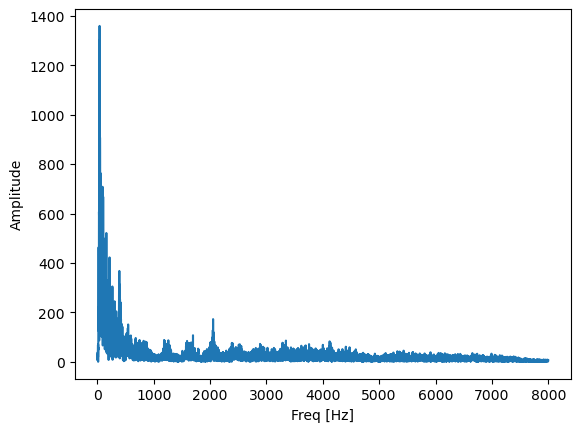

In [15]:
N = data.shape[0]
T = 1.0 / samplerate
yf = fft(data, )
xf = fftfreq(N, T)[:N//2]

plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel('Freq [Hz]')
plt.ylabel('Amplitude')
plt.show()
plt.close()

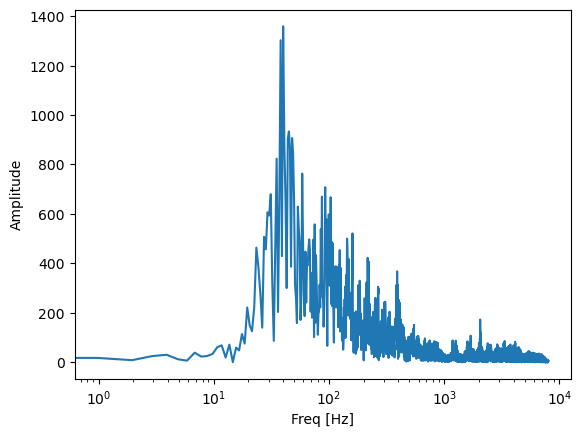

In [16]:
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel('Freq [Hz]')
plt.ylabel('Amplitude')
plt.semilogx()
plt.show()
plt.close()

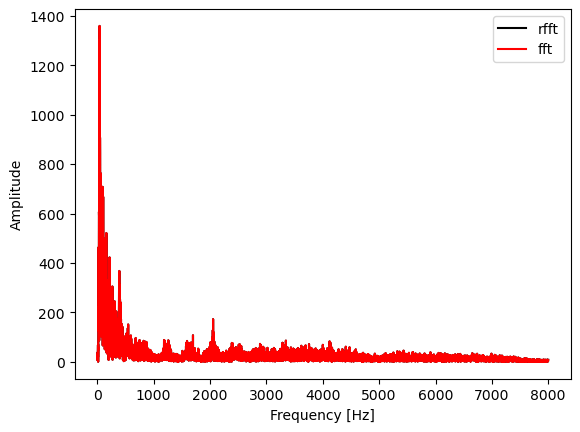

In [17]:

yfr = rfft(data)
xfr = rfftfreq(N, T)

yf = fft(data)
xf = fftfreq(N, T)[:N//2]

plt.plot(xfr, np.abs(yfr) * 2.0 / N, label='rfft', color='k')
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]), label='fft', color='r', linestyle='solid')
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.show()


Lets look at the residuals from `rff` vs `fff`

Text(0.5, 0, 'Frequency [Hz]')

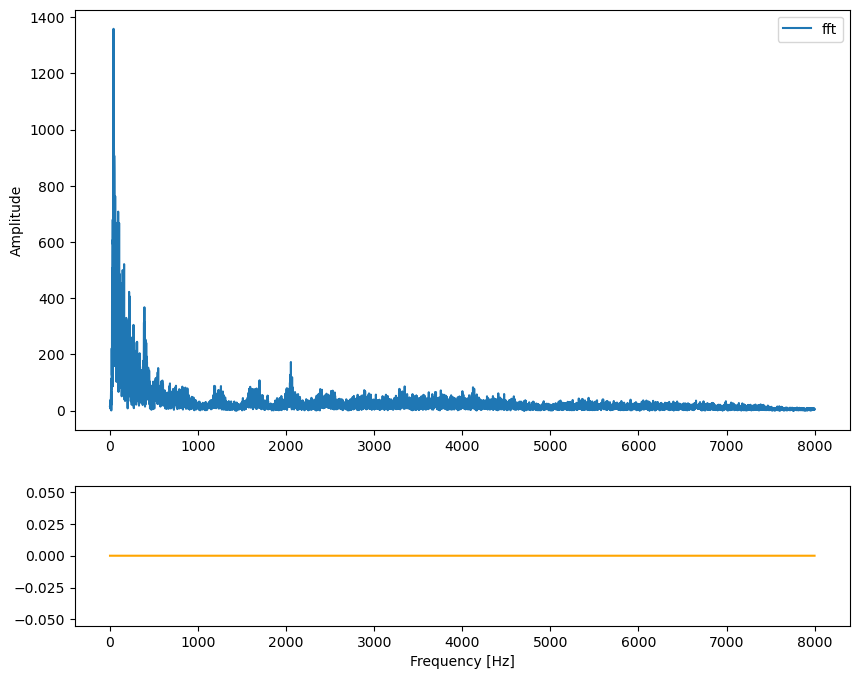

In [18]:
from matplotlib import gridspec

fig = plt.figure(figsize=(10,8))

gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
ax_main = plt.subplot(gs[0])
ax_main.plot(xf, 2.0/N * np.abs(yf[0:N//2]), label='fft')
ax_main.set_ylabel('Amplitude')
ax_main.legend()    

ax_residuals = plt.subplot(gs[1], sharex=ax_main)
residuals = (2.0/N * np.abs(yf[0:N//2])) - (2.0/N * np.abs(yfr[:-1]))
ax_residuals.plot(xf, residuals, label='Residuals', color='orange')
ax_residuals.set_xlabel('Frequency [Hz]')

### Freq peak
Chat about getting the peaks from data

40.0 Hz, amplitude 1358.691
92.8 Hz, amplitude 708.183
160.2 Hz, amplitude 521.262
67.4 Hz, amplitude 496.898
124.0 Hz, amplitude 453.911
216.8 Hz, amplitude 422.604
390.6 Hz, amplitude 367.863
184.6 Hz, amplitude 330.039
266.6 Hz, amplitude 305.127
307.6 Hz, amplitude 244.895


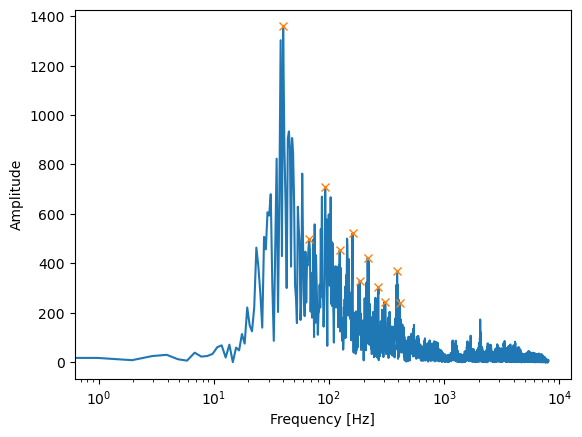

In [19]:
samplerate, data = wavfile.read('/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/yes_drone/B_S2_D1_067-bebop_000_.wav')

N = data.shape[0]
T = 1.0 / samplerate

yf = rfft(data)
xf = rfftfreq(N, T)

magnitude = np.abs(yf) * 2.0 / N

peaks, properties = find_peaks(magnitude, prominence=200, distance=20)

peak_freqs = xf[peaks]
peak_amps  = magnitude[peaks]

idx = np.argsort(peak_amps)[::-1]

peak_freqs = peak_freqs[idx]
peak_amps  = peak_amps[idx]

for f, a in zip(peak_freqs[:10], peak_amps[:10]):
    print(f"{f:.1f} Hz, amplitude {a:.3f}")

plt.plot(xf, magnitude)
plt.plot(xf[peaks], magnitude[peaks], 'x')
plt.semilogx()
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.show()

#from scipy.ndimage import gaussian_filter1d
#magnitude_smooth = gaussian_filter1d(magnitude, sigma=2)

# Try with librosa

We still want to get the:

* chromagram
* spectral center
* spectral bandwidth
* zero crossing rate
* MFCC

We should probably stick with native `sr` over librosa's default (22050 Hz). 

In [20]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
y, sr = librosa.load(base + filename, mono=True, sr=None) #keep native sr
#y, sr = librosa.load(base + filename, mono=True)

In [21]:
n_fft = 2048
hop_length = 512
#cmap = 'gray_r'
cmap = 'gray'
#cmap = 'magma'

chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)
mfcc = librosa.feature.mfcc(y=y, sr=sr)
S, phase = librosa.magphase(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length))

#ref = np.max(S)
ref=1 #set dB ref to be 1

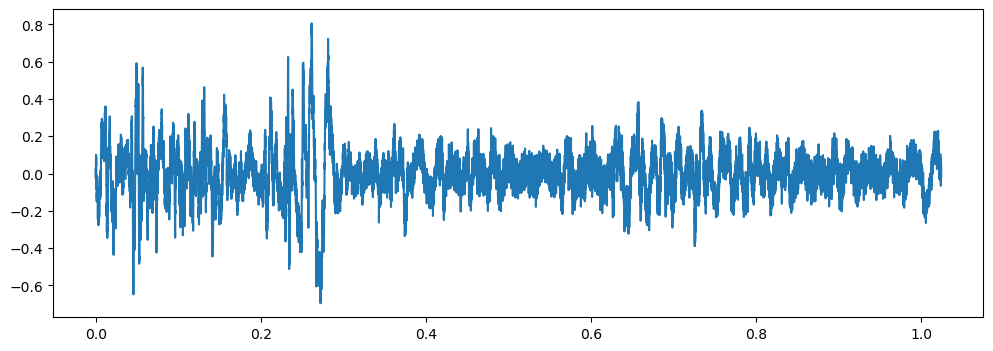

In [22]:
plt.figure(figsize=(12, 4))
time = [i / sr for i in range(len(y))]

plt.plot(time, y)
plt.show()

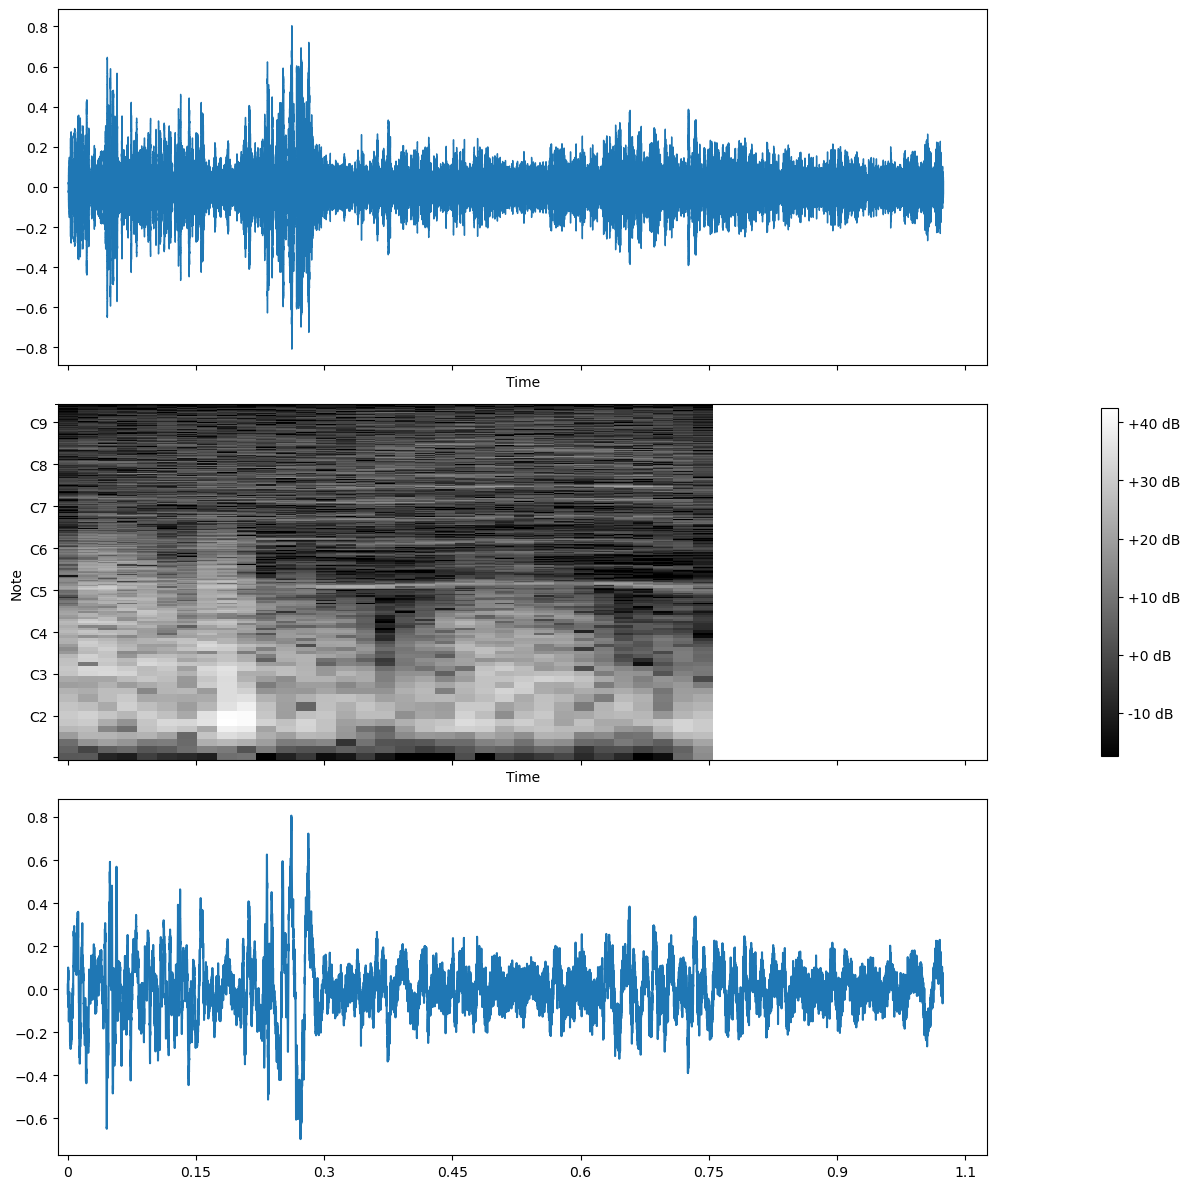

In [23]:
fig, ax = plt.subplots(figsize=(12,12), nrows=3, ncols=2, sharex=True, width_ratios=[8,1])

librosa.display.waveshow(y, sr=sr, ax=ax[0][0])

img = librosa.display.specshow(librosa.amplitude_to_db(S, ref=ref, top_db=60), y_axis='fft_note', 
                               x_axis='time', cmap=cmap, ax=ax[1][0])
ax[2][0].plot(time, y)
fig.colorbar(img, ax=ax[1][1], format="%+2.0f dB")
ax[0][1].set_axis_off()
ax[1][1].set_axis_off()
ax[2][1].set_axis_off()
plt.tight_layout()
plt.show()
plt.close()

## Look at features

Well that was easy... 

Lets look at each of these breifly

### chroma

In [24]:
chroma_stft.shape

(12, 33)

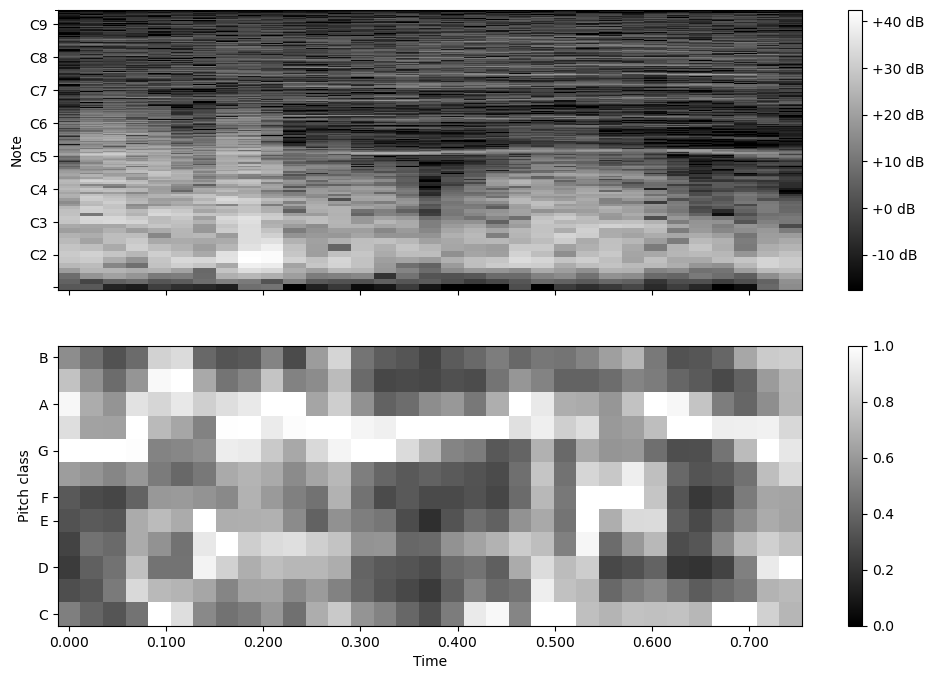

In [25]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, sharex=True)
img = librosa.display.specshow(librosa.amplitude_to_db(S=S, ref=ref, top_db=60),
                               y_axis='fft_note', x_axis='time', ax=ax[0], cmap=cmap)
fig.colorbar(img, ax=[ax[0]], format="%+2.0f dB")
ax[0].label_outer()
img = librosa.display.specshow(chroma_stft, y_axis='chroma', x_axis='time', 
                               ax=ax[1], cmap=cmap, vmin=0, vmax=1)
fig.colorbar(img, ax=[ax[1]])
plt.show()
plt.close()

In [26]:
chroma_stft.shape

(12, 33)

### Spectral Center

In [27]:
freqs, times, mags = librosa.reassigned_spectrogram(y=y, sr=sr, fill_nan=True) ##look here

In [28]:
mags[0]

array([1.4628122 , 1.4738938 , 0.35662916, 0.29095608, 0.7438304 ,
       0.48277065, 0.40895924, 0.31542474, 2.7181308 , 2.9882147 ,
       0.13931787, 0.32502943, 0.63597685, 0.18662451, 0.24925719,
       0.6794605 , 0.24415554, 0.13412432, 0.12546803, 0.12801439,
       1.1224996 , 0.11248141, 0.6808129 , 0.4631105 , 0.64291906,
       0.9111    , 0.42085883, 0.71714973, 0.40110308, 0.13399012,
       0.1904576 , 2.3244798 , 5.863624  ], dtype=float32)

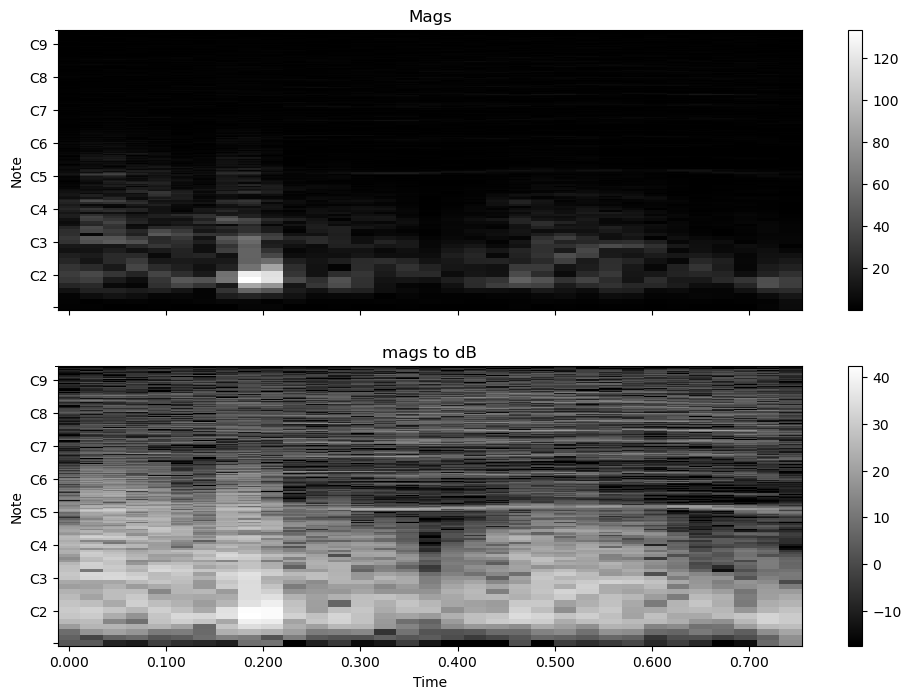

In [29]:
fig, ax = plt.subplots(figsize=(12, 8), nrows=2, sharex=True)
img = librosa.display.specshow(mags, y_axis='fft_note', x_axis='time', cmap=cmap, ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title="Mags")
ax[0].label_outer()
img = librosa.display.specshow(librosa.amplitude_to_db(mags, ref=1, top_db=60), 
                               y_axis='fft_note', x_axis='time', cmap=cmap, ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
ax[1].set(title="mags to dB")
ax[1].label_outer()
plt.show()
plt.close()

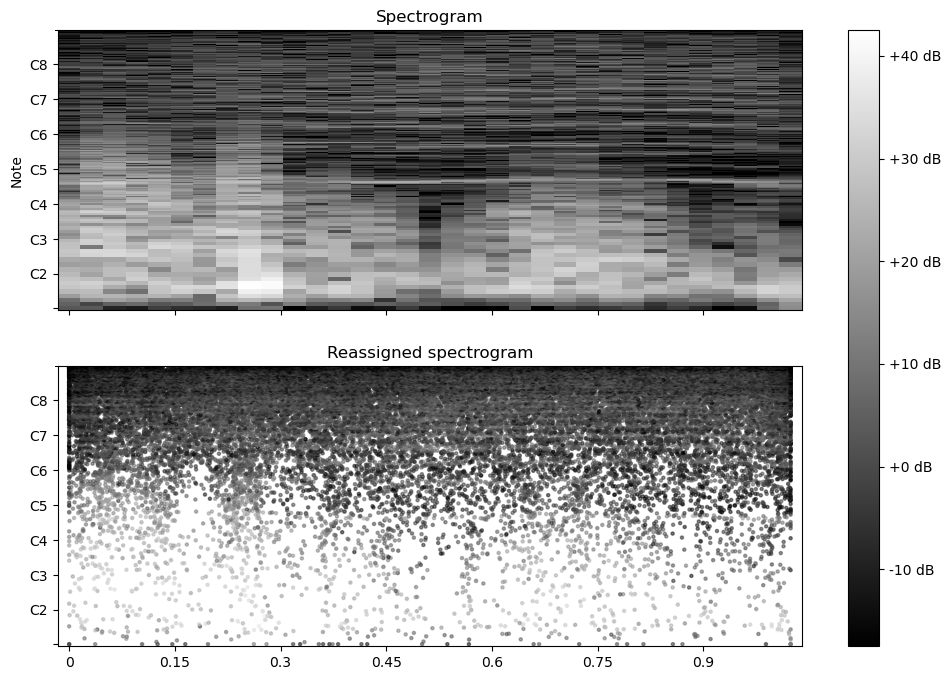

In [30]:
freqs, times, mags = librosa.reassigned_spectrogram(y=y, sr=sr, 
                                                    n_fft=n_fft, fill_nan=True)
mags_db = librosa.amplitude_to_db(mags, ref=ref, top_db=60)

fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(12,8))
img = librosa.display.specshow(mags_db, x_axis='s', y_axis="fft_note", 
                               sr=sr, ax=ax[0], cmap=cmap)
ax[0].set(title="Spectrogram")
ax[0].label_outer()
ax[1].scatter(times, freqs, c=mags_db, cmap=cmap, alpha=0.5, s=5)
ax[1].set_title("Reassigned spectrogram")
fig.colorbar(img, ax=ax, format="%+2.f dB")
plt.show()
plt.close()

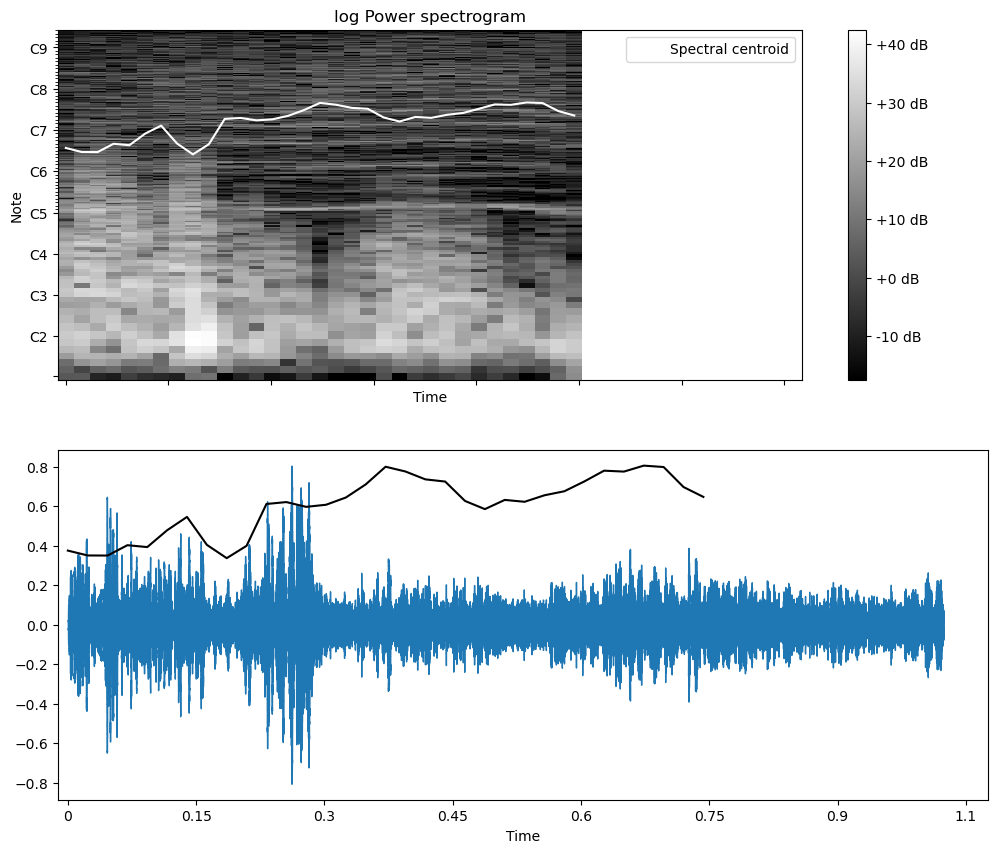

In [31]:
times = librosa.times_like(spec_cent)

fig, ax = plt.subplots(figsize=(12, 10), nrows=2, sharex=True)
img = librosa.display.specshow(librosa.amplitude_to_db(S, ref=ref, top_db=60),
                         y_axis='fft_note', x_axis='time', ax=ax[0], cmap=cmap)
plt.colorbar(img, ax=ax[0], format="%+2.0f dB")
ax[0].plot(times, spec_cent.T, label='Spectral centroid', color='w')
ax[0].legend(loc='upper right')
ax[0].set(title='log Power spectrogram')
librosa.display.waveshow(y, sr=sr, ax=ax[1])
scale =  np.max(y) / np.max(spec_cent)
ax[1].plot(times, scale * spec_cent.T, label='Spectral centroid', color='k')

plt.show()
plt.close()

### Spectral bandwidth

In [32]:
spec_bw.shape

(1, 33)

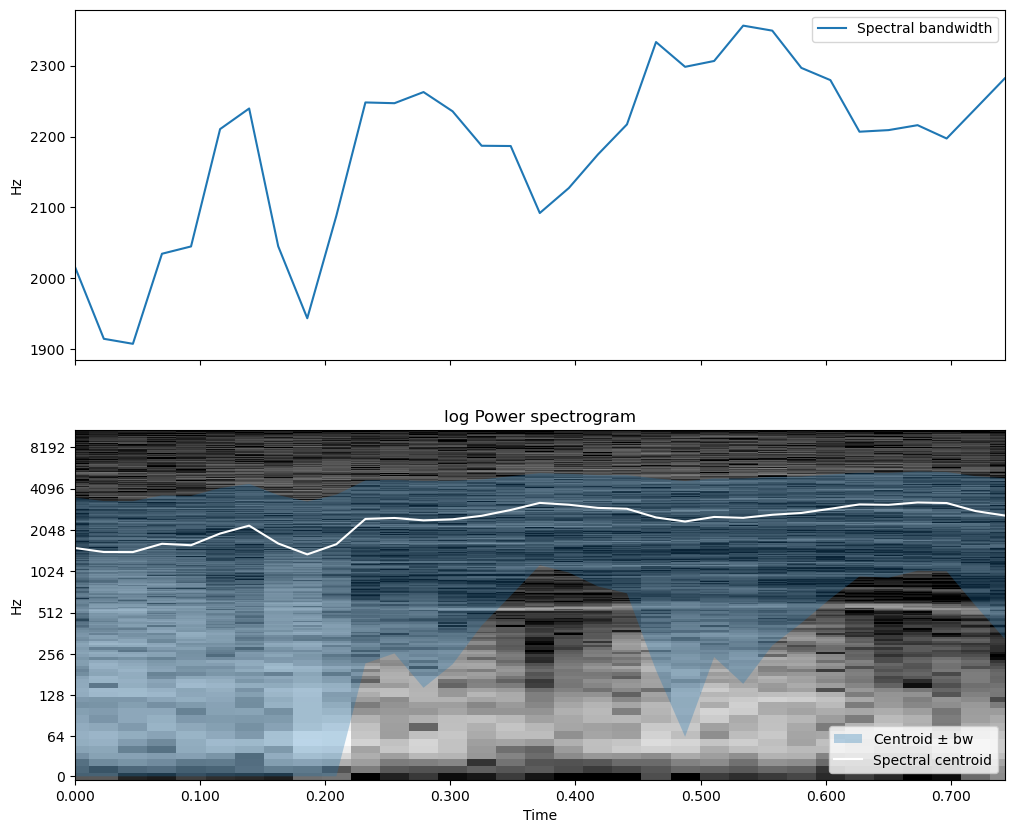

In [33]:
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(12, 10))
times = librosa.times_like(spec_bw)
ax[0].plot(times, spec_bw[0], label='Spectral bandwidth')
ax[0].set(ylabel='Hz', xticks=[], xlim=[times.min(), times.max()])
ax[0].legend()
ax[0].label_outer()
librosa.display.specshow(librosa.amplitude_to_db(S, ref=1, top_db=60),
                         y_axis='log', x_axis='time', ax=ax[1], cmap=cmap)
ax[1].set(title='log Power spectrogram')
ax[1].fill_between(times, np.maximum(0, spec_cent[0] - spec_bw[0]),
                np.minimum(spec_cent[0] + spec_bw[0], sr/2),
                alpha=0.3, label=r'Centroid $\pm$ bw')
ax[1].plot(times, spec_cent[0], label='Spectral centroid', color='w')
ax[1].legend(loc='lower right')
plt.show()
plt.close()

### Rolloff

In [34]:
rolloff.shape

(1, 33)

In [35]:
rolloff99 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.99)
rolloff1 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.01)

rolloff975 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.975)
rolloff025 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.025)

rolloff1587 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.1587)
rolloff8413 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.8413)

rolloff50 = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.50)

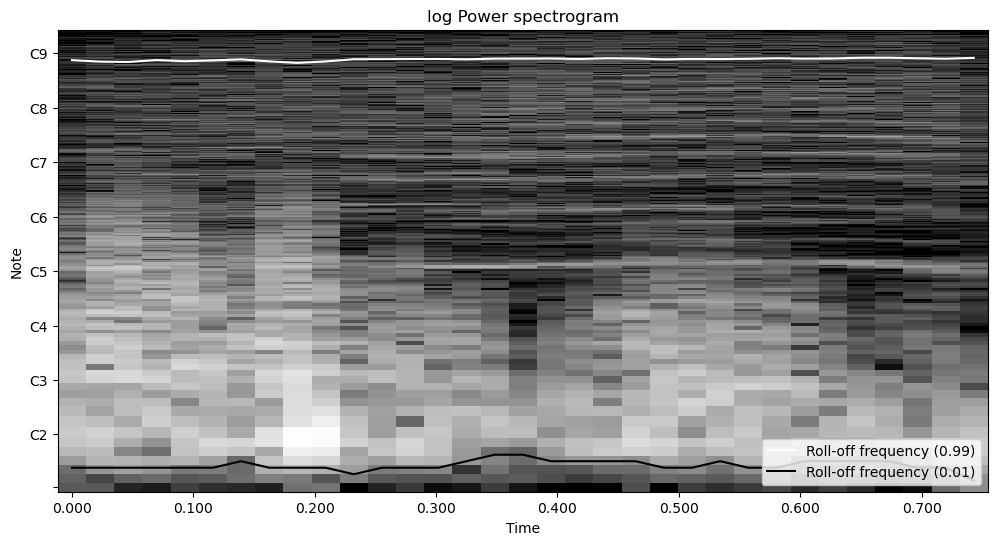

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))
librosa.display.specshow(librosa.amplitude_to_db(S, ref=1, top_db=60),
                         y_axis='fft_note', x_axis='time', ax=ax, cmap=cmap)
ax.plot(librosa.times_like(rolloff), rolloff99[0], color='w', label='Roll-off frequency (0.99)')
ax.plot(librosa.times_like(rolloff), rolloff1[0], color='k',
        label='Roll-off frequency (0.01)')
ax.legend(loc='lower right')
ax.set(title='log Power spectrogram')
plt.show()
plt.close()

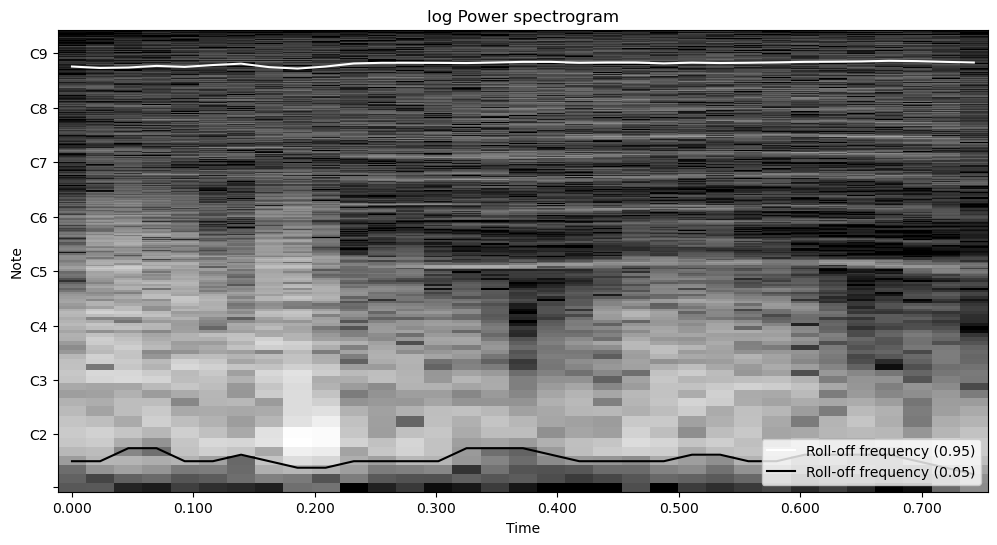

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))
librosa.display.specshow(librosa.amplitude_to_db(S, ref=1, top_db=60),
                         y_axis='fft_note', x_axis='time', ax=ax, cmap=cmap)
ax.plot(librosa.times_like(rolloff), rolloff975[0], color='w', label='Roll-off frequency (0.95)')
ax.plot(librosa.times_like(rolloff), rolloff025[0], color='k',
        label='Roll-off frequency (0.05)')
ax.legend(loc='lower right')
ax.set(title='log Power spectrogram')
plt.show()
plt.close()

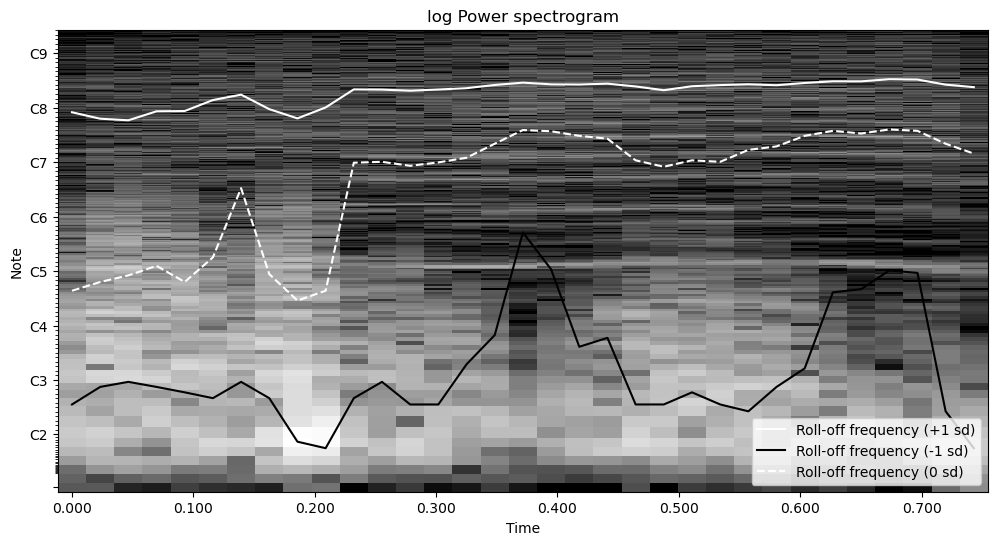

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
librosa.display.specshow(librosa.amplitude_to_db(S, ref=1, top_db=60),
                         y_axis='fft_note', x_axis='time', ax=ax, cmap=cmap)
ax.plot(librosa.times_like(rolloff), rolloff8413[0], color='w', label='Roll-off frequency (+1 sd)')
ax.plot(librosa.times_like(rolloff), rolloff1587[0], color='k',
        label='Roll-off frequency (-1 sd)')
ax.plot(librosa.times_like(rolloff), rolloff50[0], color='w', linestyle='--',
        label='Roll-off frequency (0 sd)')
ax.legend(loc='lower right')
ax.set(title='log Power spectrogram')
plt.show()
plt.close()

### ZCR

In [39]:
zcr.shape

(1, 33)

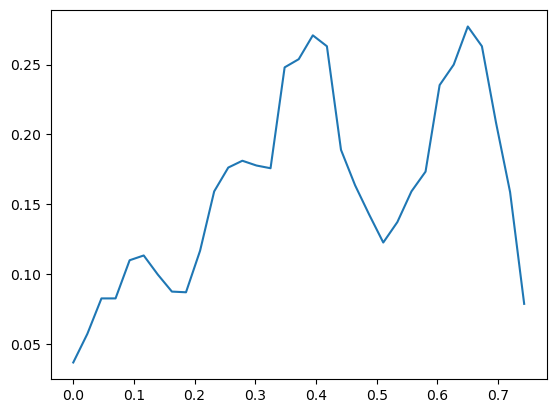

In [40]:
plt.plot(times, zcr.T)
plt.show()
plt.close()

### MFCC

MFCC (mel frequency cepstral coefficents) are a small set of features (~10-20) which describe the shape of teh spectral envelope. Used to describe timbre of sound. Orignally used for voice regonition, now used for deep learning. 

Audio input is used to make a log power spectrum (FFT) in the mel scale (represents frequency as human perceived pitch, log freq to linear perception in humans). Discrete cosine transform is applied and dimensionality reduction occurs to mel filter bank. 

In [41]:
mfcc.shape

(20, 33)

This was calculated with the default `n_mfcc=20` and `dct_type=2`. Lets look at which one is best to use right now.

DCT_I: not commonly used

DCT-II: has the most energy compaction

DCT_III: transfrom of DCT-III, used to inverse DCT_II

Lets stick with the defaults for now.

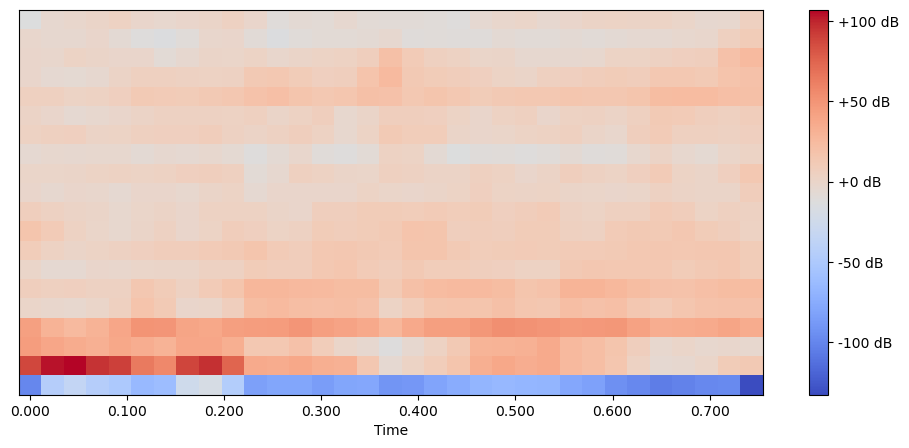

In [42]:
fig, ax = plt.subplots(figsize=(12,5))
img = librosa.display.specshow(mfcc, ax=ax, x_axis='time')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.show()
plt.close()

#### from librosa

following the example from docs: https://librosa.org/doc/latest/generated/librosa.feature.mfcc.html#librosa.feature.mfcc

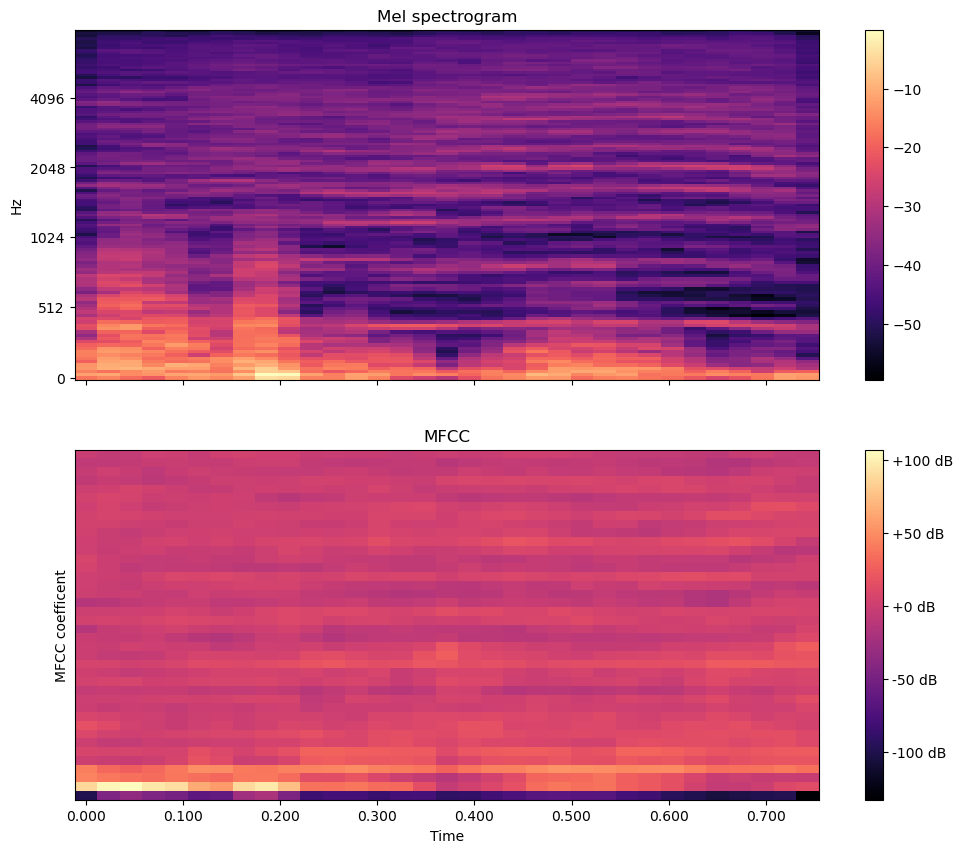

In [43]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
y, sr = librosa.load(base + filename, mono=True, sr=None)

n_fft = 2048
hop_length = 512
#cmap = 'gray_r'
cmap = 'gray'
cmap = 'magma'

mfcc = librosa.feature.mfcc(y=y, sr=sr)
librosa.feature.mfcc(y=y, sr=sr)

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                   fmax=8000)
librosa.feature.mfcc(S=librosa.power_to_db(S))

mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(12,10))
img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max),
                               x_axis='time', y_axis='mel', fmax=8000,
                               ax=ax[0], cmap=cmap)
fig.colorbar(img, ax=[ax[0]])
ax[0].set(title='Mel spectrogram')
ax[0].label_outer()
img = librosa.display.specshow(mfccs, x_axis='time', ax=ax[1], cmap=cmap)
fig.colorbar(img, ax=[ax[1]], format='%+2.0f dB')
ax[1].set(title='MFCC')
ax[1].set_ylabel('MFCC coefficent')
plt.show()
plt.close()

### Harmonics 

I will loosly follow the example from librosa at https://librosa.org/doc/0.11.0/auto_examples/plot_spectral_harmonics.html#sphx-glr-auto-examples-plot-spectral-harmonics-py

In [44]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
y, sr = librosa.load(base + filename, mono=True, sr=None)

n_fft = 2048
hop_length = 512
#cmap = 'gray_r'
cmap = 'gray'
cmap = 'magma'

#estimate fundemental freq (f0)
## note, by default pyin sets f0[n]=np.nan when voicing[n]=False
#outputs
#f0: sequence of fundamental freq estimates
#voicing: sequence of indicator vars for whether 
### there was an f0 found at each step
#voicing_probability: sequence of probs that each
### time step contains an f0
f0, voicing, voicing_probability = librosa.pyin(y=y, sr=sr, 
                                                fmin=30, fmax=6000)
S = np.abs(librosa.stft(y))


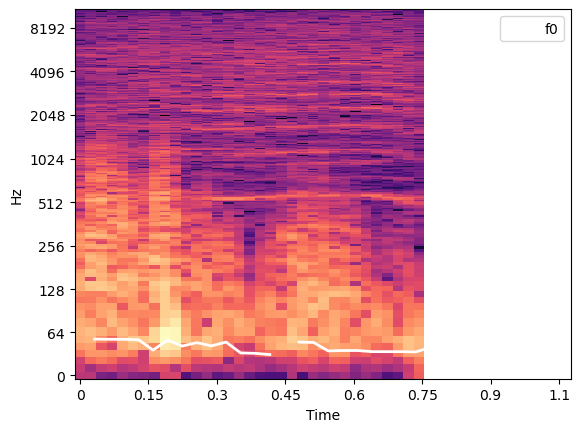

In [45]:
times = librosa.times_like(S, sr=sr)

#show how f0 contour follows the lowest freq with the most energy
fig, ax = plt.subplots()
librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax)
ax.plot(times, f0, linewidth=2, color='white', label='f0')
ax.legend()
plt.show()
plt.close()

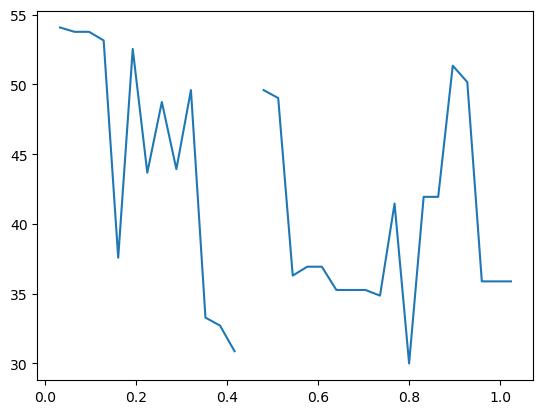

In [46]:
plt.plot(times, f0)
plt.show()
plt.close()

use `librosa.f0_harmonics` to extract energy from harmomics relative to $f_0$

In [47]:
#first 30 harmonics, 1-30
harmonics = np.arange(1, 31)

frequencies = librosa.fft_frequencies(sr=sr)

harmonic_energy = librosa.f0_harmonics(S, f0=f0, 
                                       harmonics=harmonics, freqs=frequencies)

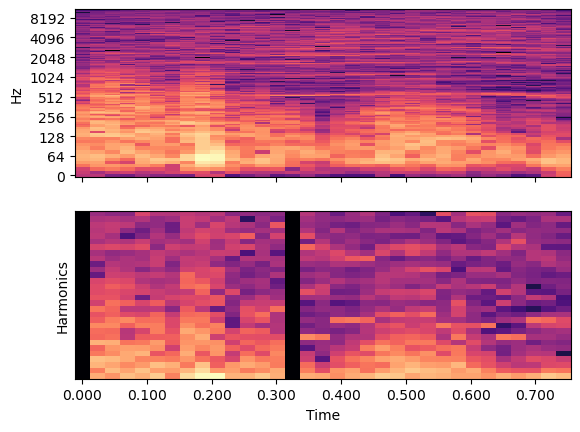

In [48]:
fig, ax = plt.subplots(nrows=2, sharex=True)

librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max),
                         y_axis='log', x_axis='time', ax=ax[0])
librosa.display.specshow(librosa.amplitude_to_db(harmonic_energy, ref=np.max),
                         x_axis='time', ax=ax[1])
ax[0].label_outer()
ax[1].set(ylabel='Harmonics')
plt.show()
plt.close()

The same patterns are here without moving relative to $f_0$ (not that different for us bs $f_0$ is fairly consistant.

# Full feature stack attempt

## Info about data
Looking at a sample of the files, it looks like all are sampled at `sr=16000` (16 KHz). 

There are 1332 `yes_drone` files and 10372 `unknown` files. This relates to a 11:89 yes-unknown split.

All of the `yes_drone` files are ~1 sec. ~18% of files are $\lt 33 \text{ kB}$, the rest are $33 \text{ kB}$:

* 0.65 - 1.024 sec
* 21 - 33 kB
* 10399 - 16384 samples(238/1332 are *not* 33kB)

The data in `unknown` files is slightly more variable. Still sampled at `sr=16kHz`, but more variation is sample length: 67 (0.7%) ( files are $\gt 159 \text{ kB}$ (79360 samples, 4.96 sec) and 2 (0.02%) samples are $\lt 24 \text{ kB}$ (11888 samples, 0.743 sec, see below). 
2 samples $\lt 24 \text{ kB}$:
* 126, 2610 (3 kB) bytes
* 24, 1266 samples
* 0.0015, 0.079 sec

max:
* 164 kB
* 81920 samples
* 5.12 sec

This relates to 10303 files (99.33%) within "normal" range, with most being $\sim 33 \text{ kB}$ (16000 samples, 1.02 sec):

min (outliers removed):
* 24 kB
* 11888 samples
* 0.743 sec

max (outliers removed):
* 39 kB
* 19550 samples
* 1.22 sec

In [49]:
numYes = 1332
numUnknown = 10372
numTotal = numYes + numUnknown
perYes = numYes / numTotal

print(f'{perYes*100:.2f}% files are labeled as yes_drone')
print(f'{perYes:.2f}:{1-perYes:.2f} yes-unknown split ')

11.38% files are labeled as yes_drone
0.11:0.89 yes-unknown split 


This indicates we should have some sort of normalization, and most files should not change significantly due to normalization. 

## Normalization, pre-process

We will normalize to have a fixed duration and consistent gain and sample rate. We'll set the normalize level to be the max of the `yes_drone` info. For longer clips we will apply a sliding window to get all of the info in the clip. This is essentaily splitying the longer clips into smaller $\sim 1 \text{ s}$ clips.

We care about frequency resolution more than time resolution, so we want a larger `n_fft` value, set at 1024 Hz. 

We will set `hop_length` to be $\text{hop_length}\approx \text{n_fft} /4 = 256$, as is standard. This leads to a timing resolution of $\Delta t = \frac{\text{hop_length}}{\text{sr}}\approx 16 \text{ ms}$ and frequenecy resolution of $\Delta f = \frac{\text{sr}}{n_{fft}}\approx15.6 \text{ Hz}$

In [50]:
base = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
filename = 'yes_drone/B_S2_D1_067-bebop_000_.wav'
y, sr = librosa.load(base + filename, mono=True, sr=16000)

In [51]:
DURATION = 1.024 #sec
SR = 16000
LENGTH_N = int(SR * DURATION) #samples
N_FFT = int(1024)
HOP_LENGTH = int(N_FFT / 4)

In [52]:
def fix_length(y, target_len):
    if len(y) > target_len:
        return y[:target_len]
    else:
        return np.pad(y, (0, target_len-len(y)))
    
def preprocess(path):
    yRaw, _ = librosa.load(path, mono=True, sr=SR)
    yNorm = librosa.util.normalize(yRaw)
    y = fix_length(yNorm, LENGTH_N)
    return y

## Feature extraction

For drones, the sound signals are likely:

* highly periodic
* harmonic
* dominated by low-mid freqs
* relativly stable over ~1 s

So we want to look at features that show periodic, harmonic, spectral shape, and stability.

In [53]:
#extract mel scaled spectrogram 
def mel_features(y, sr=SR):
    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=96,          
        fmin=50,            
        fmax=6000           
    )
    return librosa.power_to_db(S)

In [54]:
#get harmonic and percussive components
#remove rind noise, transients
def harmonic_percussive(y):
    y_harm, y_perc = librosa.effects.hpss(y)
    return y_harm

Spectral features
* centroid: where energy sits
* bandwidth: energy spread
* rolloff: high-frequency tail
* flatness: tonal vs noisy

In [55]:
def spectral_features(y, sr=SR):
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    flatness = librosa.feature.spectral_flatness(y=y)
    
    return np.vstack([centroid, bandwidth, rolloff, flatness])

Temporal features

In [56]:
def modulation_feature(y, sr=SR):
    envelope = np.abs(librosa.stft(y, n_fft=512))
    env_mean = np.mean(envelope, axis=0)
    
    mod_spec = np.abs(np.fft.rfft(env_mean))
    return mod_spec

MFCC

In [57]:
def mfcc_features(y, sr=SR):
    return librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13 #13-20
    )

Full extraction

In [58]:
mel = mel_features(y, sr)
mel_harm = mel_features(harmonic_percussive(y), sr)
delta = librosa.feature.delta(mel) #time derivative of spectrogram 

X = np.stack([mel, mel_harm, delta], axis=0)

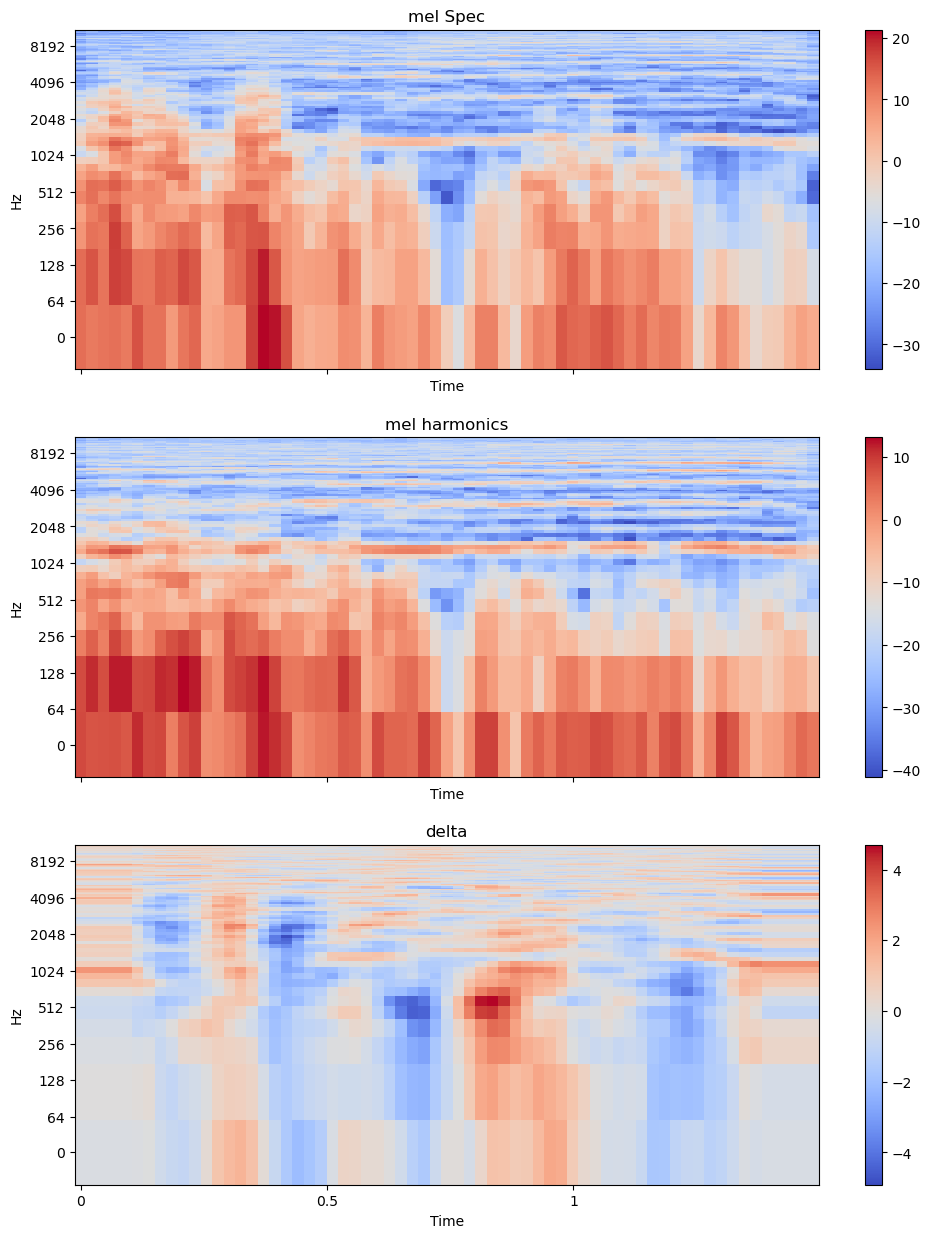

In [59]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(12,15))

img=librosa.display.specshow(X[0],
                         y_axis='log', x_axis='time', ax=ax[0])
fig.colorbar(img, ax=[ax[0]])
img=librosa.display.specshow(X[1],
                         y_axis='log', x_axis='time', ax=ax[1])
fig.colorbar(img, ax=[ax[1]])
img=librosa.display.specshow(X[2],
                         y_axis='log', x_axis='time', ax=ax[2])
fig.colorbar(img, ax=[ax[2]])
ax[0].set_title('mel Spec')
ax[1].set_title('mel harmonics')
ax[2].set_title('delta')
plt.show()
plt.close()

## Feature extraction 2

save mean and std info for features

In [60]:
#returns mean and std for features of y
#list with:
#m20 mfccMean, 20 mfccStd, #specCentMean, #specCentStd, #specBandtMean, #specBandStd,
##specRollMean, #specRollStd, #7 specConttMean, #7 specContStd, #harmEnergy, percEnergy,
#zcrMean, zcrStd, 12 chromaMean, 12 chromaStd -> 88 features
def extract_features(y, sr=SR):
    features = []

    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))

    # mffcs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # spectral features
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))

    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))

    # harmonic and percusive 
    y_harm, y_perc = librosa.effects.hpss(y)

    harm_energy = np.sum(y_harm**2)
    perc_energy = np.sum(y_perc**2)

    features.append(harm_energy)
    features.append(perc_energy)

    # sero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # chromagrams
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.extend(np.mean(chroma, axis=1))
    features.extend(np.std(chroma, axis=1))

    return np.array(features)

In [61]:
X = extract_features(y)

In [62]:
print(X.shape)

(88,)


In [63]:
def split_into_windows(y, window_size=LENGTH_N, hop=int(LENGTH_N/2)):
    windows = []
    for i in range(0, len(y) - window_size + 1, hop):
        windows.append(y[i:i+window_size])
    return windows

In [64]:
mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel)